In [1]:
# import frameworks
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
# load dataset
df=pd.read_csv('ITC_Hotels.csv') 
# check dataframe first 5 rows
df.head()

,Booking_ID,Hotel_Name,Hotel_Category,City,State,Country,Checkin_Date,Checkout_Date,Month,Quarter,...,Net_Revenue,GST_Amount,Total_With_GST,Booking_Channel,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact_Level
0,BK9835534,ITC Kakatiya,Luxury,Hyderabad,Telangana,India,44320,44324,May,Q2,...,89160,10699.20,99859.20,Walk-in,Regular,UPI,Checked-Out,4.6,Positive,High
1,BK7803377,ITC Royal Bengal,Luxury,Kolkata,West Bengal,India,44352,44356,June,Q2,...,86830,10419.60,97249.60,Corporate,VIP,Credit Card,Checked-In,4.6,Positive,High
2,BK3686278,ITC Grand Goa,Resort,Goa,Goa,India,44443,44445,September,Q3,...,29389,3526.68,32915.68,Booking.com,Corporate,Cash,Checked-In,4.2,Positive,Low
3,BK7514886,Fortune Select Trinity,Business,Bengaluru,Karnataka,India,44469,44470,September,Q3,...,24409,2929.08,27338.08,Website,Regular,Debit Card,Cancelled,3.8,Neutral,Low
4,BK6312815,ITC Narmada,Business,Ahmedabad,Gujarat,India,44461,44463,September,Q3,...,9940,1192.80,11132.80,Walk-in,New Guest,UPI,Checked-In,4.6,Negative,Low


In [3]:
# checking total rows and columns
df.shape

(300000, 28)

In [4]:
# checking columns name
df.columns

Index(['Booking_ID', 'Hotel_Name', 'Hotel_Category', 'City', 'State',
       'Country', 'Checkin_Date', 'Checkout_Date', 'Month', 'Quarter', 'Year',
       'Room_Type', 'Guests', 'Nights_Stayed', 'Room_Rate', 'Extra_Charges',
       'Discount', 'Gross_Revenue', 'Net_Revenue', 'GST_Amount',
       'Total_With_GST', 'Booking_Channel', 'Customer_Type', 'Payment_Mode',
       'Occupancy_Status', 'Customer_Rating', 'Feedback_Status',
       'Covid_Impact_Level'],
      dtype='str')

In [5]:
# checking missing values
df.isna().sum()

Booking_ID            0
Hotel_Name            0
Hotel_Category        0
City                  0
State                 0
Country               0
Checkin_Date          0
Checkout_Date         0
Month                 0
Quarter               0
Year                  0
Room_Type             0
Guests                0
Nights_Stayed         0
Room_Rate             0
Extra_Charges         0
Discount              0
Gross_Revenue         0
Net_Revenue           0
GST_Amount            0
Total_With_GST        0
Booking_Channel       0
Customer_Type         0
Payment_Mode          0
Occupancy_Status      0
Customer_Rating       0
Feedback_Status       0
Covid_Impact_Level    0
dtype: int64

In [6]:
# there is no missing values in this dataset

In [7]:
# checking correlation 
df.corr(numeric_only=True)

,Checkin_Date,Checkout_Date,Year,Guests,Nights_Stayed,Room_Rate,Extra_Charges,Discount,Gross_Revenue,Net_Revenue,GST_Amount,Total_With_GST,Customer_Rating
Checkin_Date,1.000000,0.999910,0.745240,0.002196,-0.002926,0.000686,-0.000189,0.003264,-0.001387,-0.001532,-0.001532,-0.001532,0.000666
Checkout_Date,0.999910,1.000000,0.745181,0.002243,0.010508,0.000693,-0.000177,0.003204,0.008185,0.008033,0.008033,0.008033,0.000674
Year,0.745240,0.745181,1.000000,0.001218,-0.001572,0.000958,0.000345,0.003381,-0.000168,-0.000319,-0.000319,-0.000319,0.000575
Guests,0.002196,0.002243,0.001218,1.000000,0.003454,-0.001674,0.000282,-0.000504,0.002582,0.002601,0.002601,0.002601,-0.001233
Nights_Stayed,-0.002926,0.010508,-0.001572,0.003454,1.000000,0.000528,0.000910,-0.004460,0.712551,0.711978,0.711978,0.711978,0.000601
Room_Rate,0.000686,0.000693,0.000958,-0.001674,0.000528,1.000000,-0.003891,0.001395,0.632432,0.631684,0.631684,0.631684,0.000858
Extra_Charges,-0.000189,-0.000177,0.000345,0.000282,0.000910,-0.003891,1.000000,-0.000526,0.060682,0.060640,0.060640,0.060640,-0.000759
Discount,0.003264,0.003204,0.003381,-0.000504,-0.004460,0.001395,-0.000526,1.000000,-0.001821,-0.046586,-0.046586,-0.046586,0.001922
Gross_Revenue,-0.001387,0.008185,-0.000168,0.002582,0.712551,0.632432,0.060682,-0.001821,1.000000,0.998997,0.998997,0.998997,0.001822
Net_Revenue,-0.001532,0.008033,-0.000319,0.002601,0.711978,0.631684,0.060640,-0.046586,0.998997,1.000000,1.000000,1.000000,0.001734


### Understand Correlation Properly

Correlation values:

+1 → perfect positive relation

0 → no relation

-1 → perfect negative relation

For prediction:

### Look at Relation with Total_With_GST

### important correlations are:
| Feature         | Correlation with Total_With_GST | Meaning            |
| --------------- | ------------------------------- | ------------------ |
| Nights_Stayed   | 0.711978                        | Strong             |
| Room_Rate       | 0.631684                        | Strong             |
| Gross_Revenue   | 0.998997                        | Extremely strong   |
| Net_Revenue     | 1.000000                        | Perfect            |
| GST_Amount      | 1.000000                        | Perfect            |
| Extra_Charges   | 0.060640                        | Very weak          |
| Discount        | -0.046586                       | Very weak          |
| Guests          | 0.002601                        | Almost no relation |
| Customer_Rating | 0.001734                        | No relation        |


In [8]:
data_df=df.drop(columns=['Country','Booking_ID','Checkin_Date','Checkout_Date','Year','Gross_Revenue','Net_Revenue','GST_Amount'])
data_df.head()

,Hotel_Name,Hotel_Category,City,State,Month,Quarter,Room_Type,Guests,Nights_Stayed,Room_Rate,Extra_Charges,Discount,Total_With_GST,Booking_Channel,Customer_Type,Payment_Mode,Occupancy_Status,Customer_Rating,Feedback_Status,Covid_Impact_Level
0,ITC Kakatiya,Luxury,Hyderabad,Telangana,May,Q2,Deluxe,3,4,22569,2390,3506,99859.20,Walk-in,Regular,UPI,Checked-Out,4.6,Positive,High
1,ITC Royal Bengal,Luxury,Kolkata,West Bengal,June,Q2,Presidential Suite,2,4,21693,4271,4213,97249.60,Corporate,VIP,Credit Card,Checked-In,4.6,Positive,High
2,ITC Grand Goa,Resort,Goa,Goa,September,Q3,Luxury Suite,1,2,14474,4243,3802,32915.68,Booking.com,Corporate,Cash,Checked-In,4.2,Positive,Low
3,Fortune Select Trinity,Business,Bengaluru,Karnataka,September,Q3,Executive,1,1,25327,2363,3281,27338.08,Website,Regular,Debit Card,Cancelled,3.8,Neutral,Low
4,ITC Narmada,Business,Ahmedabad,Gujarat,September,Q3,Deluxe,1,2,6732,1092,4616,11132.80,Walk-in,New Guest,UPI,Checked-In,4.6,Negative,Low


#### Country

Dropped because it contains mostly one constant value and does not provide useful learning information to the model.

#### Booking_ID

Dropped because it is a unique identifier and has no meaningful relationship with the target variable.

#### Checkin_Date & Checkout_Date

Dropped because raw date columns are not directly useful and their information is already represented using `Nights_Stayed`.

#### Year

Dropped because it has very low variation and weak correlation with the target variable.

#### Gross_Revenue

Dropped to avoid data leakage because it is highly related to `Total_With_GST`.

#### Net_Revenue

Dropped because it has almost perfect correlation with the target variable and can make the model cheat.

#### GST_Amount

Dropped because it directly contributes to calculating `Total_With_GST`, causing target leakage.


In [9]:
data_df.shape

(300000, 20)

In [10]:
data_df = data_df.drop(columns=['Guests','Extra_Charges','Discount','Customer_Rating'])
data_df.head()

,Hotel_Name,Hotel_Category,City,State,Month,Quarter,Room_Type,Nights_Stayed,Room_Rate,Total_With_GST,Booking_Channel,Customer_Type,Payment_Mode,Occupancy_Status,Feedback_Status,Covid_Impact_Level
0,ITC Kakatiya,Luxury,Hyderabad,Telangana,May,Q2,Deluxe,4,22569,99859.20,Walk-in,Regular,UPI,Checked-Out,Positive,High
1,ITC Royal Bengal,Luxury,Kolkata,West Bengal,June,Q2,Presidential Suite,4,21693,97249.60,Corporate,VIP,Credit Card,Checked-In,Positive,High
2,ITC Grand Goa,Resort,Goa,Goa,September,Q3,Luxury Suite,2,14474,32915.68,Booking.com,Corporate,Cash,Checked-In,Positive,Low
3,Fortune Select Trinity,Business,Bengaluru,Karnataka,September,Q3,Executive,1,25327,27338.08,Website,Regular,Debit Card,Cancelled,Neutral,Low
4,ITC Narmada,Business,Ahmedabad,Gujarat,September,Q3,Deluxe,2,6732,11132.80,Walk-in,New Guest,UPI,Checked-In,Negative,Low


---

#### Guests

Dropped because it has very weak correlation with `Total_With_GST` and contributes little to prediction.

#### Extra_Charges

Dropped because it shows very low relationship with the target variable and has minimal predictive impact.

#### Discount

Dropped because it has weak negative correlation and does not significantly influence the model output.

#### Customer_Rating

Dropped because it has almost no correlation with `Total_With_GST` and provides very little learning value.


In [11]:
data_df.shape

(300000, 16)

In [12]:
data_df.columns

Index(['Hotel_Name', 'Hotel_Category', 'City', 'State', 'Month', 'Quarter',
       'Room_Type', 'Nights_Stayed', 'Room_Rate', 'Total_With_GST',
       'Booking_Channel', 'Customer_Type', 'Payment_Mode', 'Occupancy_Status',
       'Feedback_Status', 'Covid_Impact_Level'],
      dtype='str')

In [13]:
# Checking infomration 
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Hotel_Name          300000 non-null  str    
 1   Hotel_Category      300000 non-null  str    
 2   City                300000 non-null  str    
 3   State               300000 non-null  str    
 4   Month               300000 non-null  str    
 5   Quarter             300000 non-null  str    
 6   Room_Type           300000 non-null  str    
 7   Nights_Stayed       300000 non-null  int64  
 8   Room_Rate           300000 non-null  int64  
 9   Total_With_GST      300000 non-null  float64
 10  Booking_Channel     300000 non-null  str    
 11  Customer_Type       300000 non-null  str    
 12  Payment_Mode        300000 non-null  str    
 13  Occupancy_Status    300000 non-null  str    
 14  Feedback_Status     300000 non-null  str    
 15  Covid_Impact_Level  300000 non-null  str    


#### Total Rows

The dataset contains 300000 records, which is a large dataset suitable for machine learning training.

#### No Missing Values

All columns contain 300000 non-null values, indicating there are no missing values in the dataset.

#### Numerical Columns

`Nights_Stayed`, `Room_Rate`, and `Total_With_GST` are numerical columns used for calculations and prediction.

#### Categorical Columns

Most columns are object datatype, meaning they are categorical features and need encoding before model training.

#### Target Variable

`Total_With_GST` is the target column for regression prediction.

#### Dataset Quality

The dataset is clean, structured, and ready for preprocessing and machine learning implementation.


In [14]:
data_df.describe()

,Nights_Stayed,Room_Rate,Total_With_GST
count,300000.000000,300000.000000,300000.000000
mean,3.001237,16230.221470,55682.040743
std,1.414777,6788.146877,36126.001930
min,1.000000,4500.000000,-236.320000
25%,2.000000,10357.000000,26430.880000
50%,3.000000,16212.000000,47574.800000
75%,4.000000,22124.000000,79182.880000
max,5.000000,27999.000000,163242.240000


#### Dataset Size

The statistical summary is calculated on 300000 records, providing reliable insights for analysis and modeling.

#### Nights_Stayed

Most customers stayed around 3 nights, with stays ranging from 1 to 5 nights.

#### Room_Rate

The average room rate is around 16230, with prices varying between 4500 and 27999.

#### Total_With_GST

The average total bill amount is approximately 55682, with the maximum reaching 163242.

#### Standard Deviation

High standard deviation in `Room_Rate` and `Total_With_GST` indicates significant variation in hotel pricing and billing.

#### Quartile Analysis

50% of bookings have `Total_With_GST` below approximately 47574, showing moderate spending distribution.

#### Negative Minimum Value

`Total_With_GST` contains a negative minimum value, which may indicate data entry errors, refunds, or anomalies requiring further investigation.


In [15]:
data_df.describe(include=['object']).T

,count,unique,top,freq
Hotel_Name,300000,15,ITC Mughal,20280
Hotel_Category,300000,3,Luxury,139946
City,300000,10,Bengaluru,59747
State,300000,10,Karnataka,59747
Month,300000,12,October,25842
Quarter,300000,4,Q4,75952
Room_Type,300000,5,Luxury Suite,60144
Booking_Channel,300000,6,MakeMyTrip,50159
Customer_Type,300000,5,Corporate,60259
Payment_Mode,300000,5,Cash,60111


#### Categorical Data Summary

The dataset contains multiple categorical columns representing hotel, customer, booking, and operational information.

#### Hotel_Name

There are 15 unique hotels, with `ITC Mughal` being the most frequently occurring hotel.

#### Hotel_Category

The dataset includes 3 hotel categories, with `Luxury` hotels appearing most frequently.

#### Location Features

The dataset covers 10 cities and 10 states, with `Bengaluru` and `Karnataka` having the highest booking frequency.

#### Time Features

The dataset contains all 12 months and 4 quarters, with `Q4` showing the highest number of bookings.

#### Room_Type

There are 5 room types, and `Luxury Suite` is the most commonly booked room category.

#### Booking_Channel

Bookings are generated through 6 channels, with `MakeMyTrip` being the most used platform.

#### Customer_Type

The dataset includes 5 customer types, with `Corporate` customers appearing most frequently.

#### Payment_Mode

There are 5 payment methods, and `Cash` is the most commonly used payment mode.

#### Occupancy_Status

The majority of hotel records are marked as `Checked-In`, indicating active occupancy trends.

#### Feedback_Status

Most customers provided `Positive` feedback, showing generally high customer satisfaction.

#### Covid_Impact_Level

The `Low` covid impact level appears most frequently, indicating reduced pandemic impact during most bookings.


In [16]:
# numbers based columns'
numeric_col=data_df.select_dtypes(include=['int64','float64'])
numeric_col.head()

,Nights_Stayed,Room_Rate,Total_With_GST
0,4,22569,99859.20
1,4,21693,97249.60
2,2,14474,32915.68
3,1,25327,27338.08
4,2,6732,11132.80


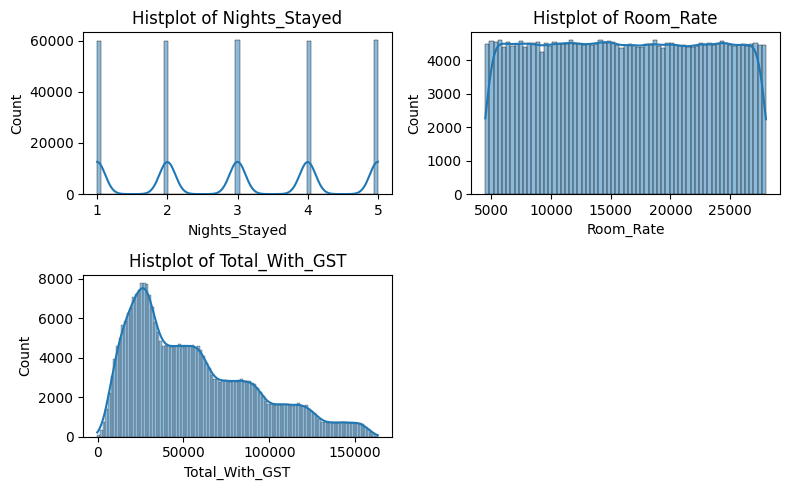

Nights_Stayed    -0.000759
Room_Rate         0.003815
Total_With_GST    0.802631
dtype: float64


In [17]:
# Distirbution Visualization

plt.figure(figsize=(8,5))

for i, col in enumerate(numeric_col, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=data_df, x=col, kde=True)
    plt.title(f'Histplot of {col}')

plt.tight_layout()
plt.show()
print(numeric_col.skew())

#### Nights_Stayed Distribution

`Nights_Stayed` shows a discrete distribution because hotel stays are limited between 1 to 5 nights.

#### Room_Rate Distribution

`Room_Rate` appears nearly uniformly distributed, indicating room prices are spread across a wide range.

#### Total_With_GST Distribution

`Total_With_GST` is positively skewed, with most bookings concentrated at lower bill amounts and fewer high-value bookings.

#### KDE Curve

The KDE line helps visualize the overall probability density and smooth distribution pattern of each numerical feature.

#### Skewness Analysis

`Total_With_GST` has high positive skewness, indicating the presence of right-tailed distribution and possible high-value outliers.

#### Low Skewness Features

`Nights_Stayed` and `Room_Rate` show skewness values close to zero, indicating relatively balanced distributions.


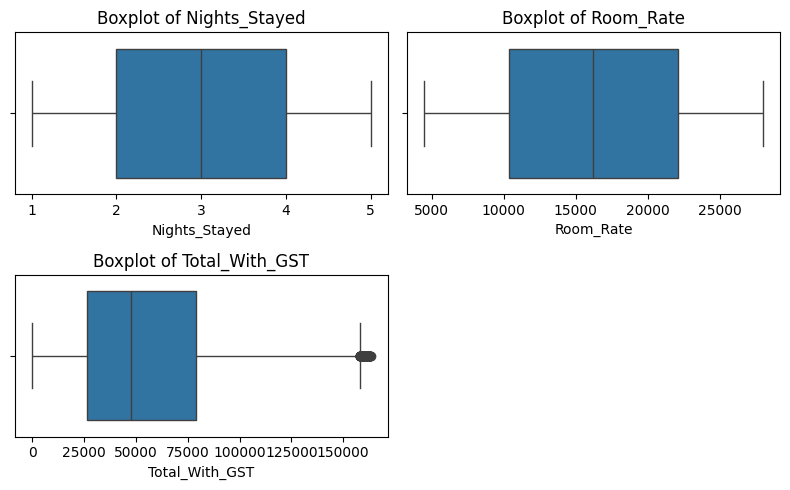

In [18]:
# checking outliers
plt.figure(figsize=(8,5))

for i, col in enumerate(numeric_col, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=data_df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

#### Nights_Stayed Boxplot

`Nights_Stayed` shows a balanced distribution with no major outliers present in the data.

#### Room_Rate Boxplot

`Room_Rate` appears evenly distributed with moderate spread and no significant extreme values.

#### Total_With_GST Boxplot

`Total_With_GST` contains some high-value outliers visible on the right side of the boxplot.

#### Median Analysis

The middle line inside each box represents the median value of the distribution.

#### IQR Analysis

The box area represents the interquartile range (IQR), showing where most data points are concentrated.

#### Outlier Detection

Boxplots help identify unusual or extreme observations that may affect machine learning model performance.


In [19]:
# checking categories based columns
category_df = data_df.select_dtypes(include=['object'])
category_df.head()


,Hotel_Name,Hotel_Category,City,State,Month,Quarter,Room_Type,Booking_Channel,Customer_Type,Payment_Mode,Occupancy_Status,Feedback_Status,Covid_Impact_Level
0,ITC Kakatiya,Luxury,Hyderabad,Telangana,May,Q2,Deluxe,Walk-in,Regular,UPI,Checked-Out,Positive,High
1,ITC Royal Bengal,Luxury,Kolkata,West Bengal,June,Q2,Presidential Suite,Corporate,VIP,Credit Card,Checked-In,Positive,High
2,ITC Grand Goa,Resort,Goa,Goa,September,Q3,Luxury Suite,Booking.com,Corporate,Cash,Checked-In,Positive,Low
3,Fortune Select Trinity,Business,Bengaluru,Karnataka,September,Q3,Executive,Website,Regular,Debit Card,Cancelled,Neutral,Low
4,ITC Narmada,Business,Ahmedabad,Gujarat,September,Q3,Deluxe,Walk-in,New Guest,UPI,Checked-In,Negative,Low


## Feature Encoding 
| Column             | Encoding Type    | Why                                                                     |
| ------------------ | ---------------- | ----------------------------------------------------------------------- |
| Hotel_Name         | Label Encoding   | Target labels can be converted into numeric classes for classification. |
| Hotel_Category     | One Hot Encoding | Small number of categories and no ranking/order present.                |
| City               | One Hot Encoding | Cities are nominal categories without hierarchy.                        |
| State              | One Hot Encoding | States are categorical labels with no ordinal relationship.             |
| Month              | Ordinal Encoding | Months follow a natural sequential order from Jan to Dec.               |
| Quarter            | Ordinal Encoding | Quarters have ordered sequence like Q1 → Q4.                            |
| Room_Type          | One Hot Encoding | Room categories are nominal and should not get numeric ranking.         |
| Booking_Channel    | One Hot Encoding | Booking platforms are independent categorical values.                   |
| Customer_Type      | One Hot Encoding | Customer categories do not contain meaningful order.                    |
| Payment_Mode       | One Hot Encoding | Payment methods are nominal categories.                                 |
| Occupancy_Status   | Label Encoding   | Small number of repeated categories suitable for label conversion.      |
| Feedback_Status    | Ordinal Encoding | Feedback can follow order like Negative < Neutral < Positive.           |
| Covid_Impact_Level | Label Encoding   | Binary category (`High`, `Low`) can be easily converted into 0 and 1.   |


In [20]:
## One Hot Encoding Code

one_hot_col = [
    'Hotel_Category',
    'City',
    'State',
    'Room_Type',
    'Booking_Channel',
    'Customer_Type',
    'Payment_Mode'
]

data_df = pd.get_dummies(data_df, columns=one_hot_col)

data_df.head()

,Hotel_Name,Month,Quarter,Nights_Stayed,Room_Rate,Total_With_GST,Occupancy_Status,Feedback_Status,Covid_Impact_Level,Hotel_Category_Business,...,Customer_Type_Corporate,Customer_Type_Member,Customer_Type_New Guest,Customer_Type_Regular,Customer_Type_VIP,Payment_Mode_Cash,Payment_Mode_Credit Card,Payment_Mode_Debit Card,Payment_Mode_Net Banking,Payment_Mode_UPI
0,ITC Kakatiya,May,Q2,4,22569,99859.20,Checked-Out,Positive,High,False,...,False,False,False,True,False,False,False,False,False,True
1,ITC Royal Bengal,June,Q2,4,21693,97249.60,Checked-In,Positive,High,False,...,False,False,False,False,True,False,True,False,False,False
2,ITC Grand Goa,September,Q3,2,14474,32915.68,Checked-In,Positive,Low,False,...,True,False,False,False,False,True,False,False,False,False
3,Fortune Select Trinity,September,Q3,1,25327,27338.08,Cancelled,Neutral,Low,True,...,False,False,False,True,False,False,False,True,False,False
4,ITC Narmada,September,Q3,2,6732,11132.80,Checked-In,Negative,Low,True,...,False,False,True,False,False,False,False,False,False,True


In [21]:
## Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

label_col = [
    'Occupancy_Status',
    'Covid_Impact_Level',
    'Hotel_Name'
]

for col in label_col:
    data_df[col] = le.fit_transform(data_df[col])

data_df.head()

,Hotel_Name,Month,Quarter,Nights_Stayed,Room_Rate,Total_With_GST,Occupancy_Status,Feedback_Status,Covid_Impact_Level,Hotel_Category_Business,...,Customer_Type_Corporate,Customer_Type_Member,Customer_Type_New Guest,Customer_Type_Regular,Customer_Type_VIP,Payment_Mode_Cash,Payment_Mode_Credit Card,Payment_Mode_Debit Card,Payment_Mode_Net Banking,Payment_Mode_UPI
0,4,May,Q2,4,22569,99859.20,2,Positive,0,False,...,False,False,False,True,False,False,False,False,False,True
1,11,June,Q2,4,21693,97249.60,1,Positive,0,False,...,False,False,False,False,True,False,True,False,False,False
2,3,September,Q3,2,14474,32915.68,1,Positive,1,False,...,True,False,False,False,False,True,False,False,False,False
3,0,September,Q3,1,25327,27338.08,0,Neutral,1,True,...,False,False,False,True,False,False,False,True,False,False
4,9,September,Q3,2,6732,11132.80,1,Negative,1,True,...,False,False,True,False,False,False,False,False,False,True


In [22]:
# Ordinal Encoding

month_order = {
    'January':1,
    'February':2,
    'March':3,
    'April':4,
    'May':5,
    'June':6,
    'July':7,
    'August':8,
    'September':9,
    'October':10,
    'November':11,
    'December':12
}

quarter_order = {
    'Q1':1,
    'Q2':2,
    'Q3':3,
    'Q4':4
}

feedback_order = {
    'Negative':0,
    'Neutral':1,
    'Positive':2
}

data_df['Month'] = data_df['Month'].map(month_order)

data_df['Quarter'] = data_df['Quarter'].map(quarter_order)

data_df['Feedback_Status'] = data_df['Feedback_Status'].map(feedback_order)

data_df.head()

,Hotel_Name,Month,Quarter,Nights_Stayed,Room_Rate,Total_With_GST,Occupancy_Status,Feedback_Status,Covid_Impact_Level,Hotel_Category_Business,...,Customer_Type_Corporate,Customer_Type_Member,Customer_Type_New Guest,Customer_Type_Regular,Customer_Type_VIP,Payment_Mode_Cash,Payment_Mode_Credit Card,Payment_Mode_Debit Card,Payment_Mode_Net Banking,Payment_Mode_UPI
0,4,5,2,4,22569,99859.20,2,2,0,False,...,False,False,False,True,False,False,False,False,False,True
1,11,6,2,4,21693,97249.60,1,2,0,False,...,False,False,False,False,True,False,True,False,False,False
2,3,9,3,2,14474,32915.68,1,2,1,False,...,True,False,False,False,False,True,False,False,False,False
3,0,9,3,1,25327,27338.08,0,1,1,True,...,False,False,False,True,False,False,False,True,False,False
4,9,9,3,2,6732,11132.80,1,0,1,True,...,False,False,True,False,False,False,False,False,False,True


In [23]:
data_df.shape

(300000, 53)

## Separate Features and Target

In [24]:
X = data_df.drop('Total_With_GST', axis=1)

y = data_df['Total_With_GST']

In [25]:
X.head(2)

,Hotel_Name,Month,Quarter,Nights_Stayed,Room_Rate,Occupancy_Status,Feedback_Status,Covid_Impact_Level,Hotel_Category_Business,Hotel_Category_Luxury,...,Customer_Type_Corporate,Customer_Type_Member,Customer_Type_New Guest,Customer_Type_Regular,Customer_Type_VIP,Payment_Mode_Cash,Payment_Mode_Credit Card,Payment_Mode_Debit Card,Payment_Mode_Net Banking,Payment_Mode_UPI
0,4,5,2,4,22569,2,2,0,False,True,...,False,False,False,True,False,False,False,False,False,True
1,11,6,2,4,21693,1,2,0,False,True,...,False,False,False,False,True,False,True,False,False,False


In [26]:
y.head(2)

0    99859.2
1    97249.6
Name: Total_With_GST, dtype: float64

## Train Test Split

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [28]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((240000, 52), (60000, 52), (240000,), (60000,))

## Apply Scaling

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

<function matplotlib.pyplot.show(close=None, block=None)>

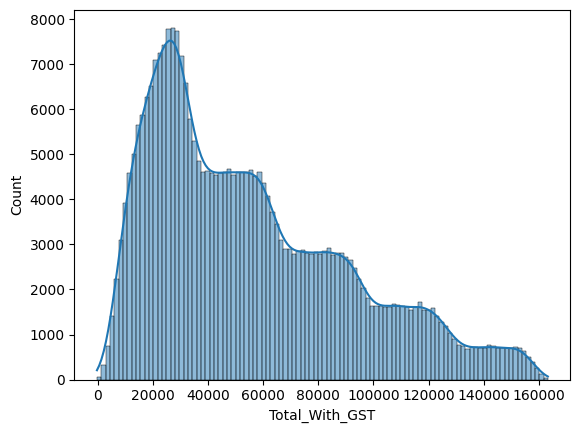

In [30]:
sns.histplot(data=data_df.Total_With_GST,kde=True)
plt.show

In [31]:
data_df['Hotel_Name'].value_counts()

Hotel_Name
8     20280
3     20144
6     20139
4     20092
10    20087
13    20085
2     20049
7     20047
14    19977
11    19925
5     19860
12    19843
1     19834
0     19828
9     19810
Name: count, dtype: int64

## Model 

In [32]:
# Import Libraries

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
# Model Training

rf_model = RandomForestRegressor(random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [34]:
# Prediction

y_pred = rf_model.predict(X_test)

In [35]:
# Model Evaluation

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2353.195287625778
MSE : 8233754.549998954
RMSE : 2869.451959869507
R2 Score : 0.993635446745007


In [36]:
# Train Score

train_score = rf_model.score(X_train, y_train)

# Test Score

test_score = rf_model.score(X_test, y_test)

print("Train Score :", train_score)

print("Test Score :", test_score)

Train Score : 0.9991138389694851
Test Score : 0.993635446745007


In [37]:
# Feature Importance

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
3,Nights_Stayed,0.526293
4,Room_Rate,0.469121
1,Month,0.000507
0,Hotel_Name,0.000436
5,Occupancy_Status,0.000274
6,Feedback_Status,0.000195
2,Quarter,0.000117
51,Payment_Mode_UPI,0.000105
33,Room_Type_Executive,0.000105
49,Payment_Mode_Debit Card,0.000105


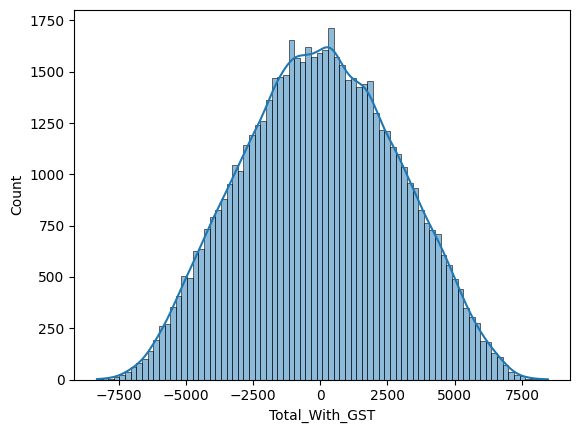

In [38]:
# Another Check — Residual Analysis

#Check prediction errors:

residuals = y_test - y_pred

#Then visualize:

sns.histplot(residuals, kde=True)
plt.show()

In [39]:
# Checking with hyperperameter method 
# using Randomsearch CV
from sklearn.model_selection import RandomizedSearchCV
# Define Model
rf_model = RandomForestRegressor(random_state=42)


In [40]:
# Hyperparameter Grid

param_grid = {
    
    'n_estimators': [50, 100, 150],
    
    'max_depth': [10, 20, 30, None],
    
    'min_samples_split': [2, 5, 10],
    
    'min_samples_leaf': [1, 2, 4],
    
    'max_features': ['sqrt', 'log2']
}

In [41]:
# Randomized Search CV

random_search = RandomizedSearchCV(
    
    estimator=rf_model,
    
    param_distributions=param_grid,
    
    n_iter=10,
    
    cv=5,
    
    scoring='r2',
    
    verbose=2,
    
    n_jobs=-1,
    
    random_state=42
)

In [42]:
# Train Model

random_search.fit(X_train, y_train)

# Best Parameters

print("Best Parameters :")

print(random_search.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters :
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 30}


In [43]:
# Best Score

print("Best Cross Validation Score :")

print(random_search.best_score_)

Best Cross Validation Score :
0.9590119000241442


In [44]:
# Best Model

best_rf_model = random_search.best_estimator_

In [45]:
# Prediction

y_pred = best_rf_model.predict(X_test)

In [46]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 5554.439407783325
MSE : 53654338.113110654
RMSE : 7324.912157364801
R2 Score : 0.9585261024956915


In [47]:
# Train Score

train_score = best_rf_model.score(X_train, y_train)

# Test Score

test_score = best_rf_model.score(X_test, y_test)

print("Train Score :", train_score)

print("Test Score :", test_score)

Train Score : 0.9827791421865248
Test Score : 0.9585261024956915


In [48]:
# Feature Importance

import pandas as pd

feature_importance = pd.DataFrame({

    'Feature': X_train.columns,

    'Importance': best_rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                   Feature  Importance
3            Nights_Stayed    0.497261
4                Room_Rate    0.413900
1                    Month    0.010236
5         Occupancy_Status    0.007308
6          Feedback_Status    0.004707
0               Hotel_Name    0.004055
2                  Quarter    0.003896
34  Room_Type_Luxury Suite    0.002334
47       Payment_Mode_Cash    0.002252
45   Customer_Type_Regular    0.002249


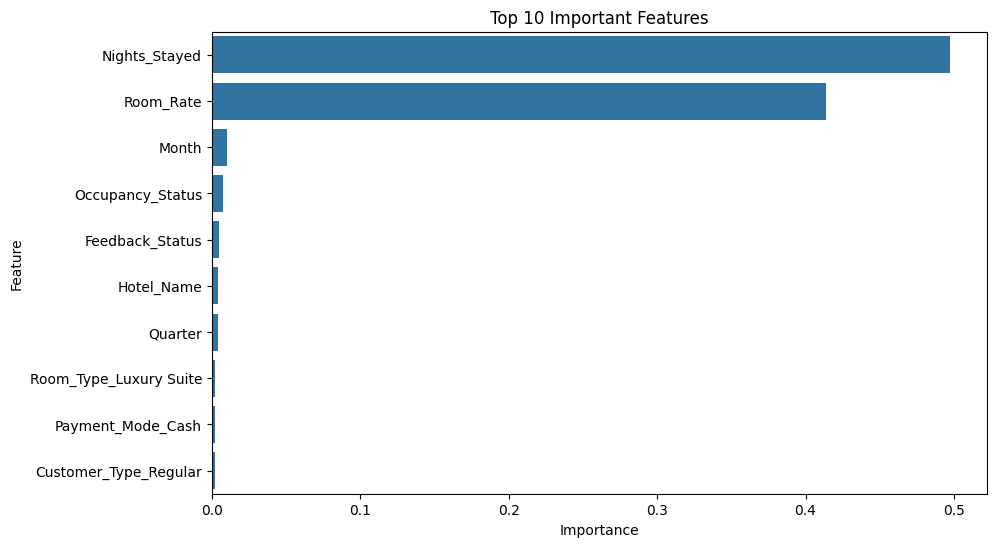

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title('Top 10 Important Features')

plt.show()

#### Train Score Analysis

The model achieved high training accuracy, indicating strong learning of training patterns.

#### Test Score Analysis

The test score remains high, showing good generalization capability on unseen data.

#### Overfitting Check

The train-test score gap is moderate, indicating controlled overfitting after hyperparameter tuning.

#### Model Stability

The tuned Random Forest model demonstrates stable and reliable predictive performance suitable for production-level consideration.

In [50]:
import joblib

In [52]:
joblib.dump(
    
    best_rf_model,
    
    'models/hotel_price_model.pkl'
)

['models/hotel_price_model.pkl']

In [53]:
joblib.dump(
    
    X.columns.tolist(),
    
    'models/model_columns.pkl'
)

['models/model_columns.pkl']